# Data Analysis

## Imports

In [21]:
import os, sys
import polars as pl
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.data_analysis_utils import (
    plot_quant_distribution,
    plot_cat_distribution
)

## File

In [22]:
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '04d_processed_data.parquet')

In [23]:
processed_data = pl.read_parquet(processed_data_path)
processed_data.head()

comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score
str,str,str,i64,f64,str,str,str,str,i64,f64,i64,f64,str,str,str,str,str,str,i64,str,i64,str,i64,str,i64,str,i64,str,f64,str
"""my7m6yl""","""1ldbowi""","""I don’t hate you as an Israeli…",7,1.7501e9,"""2025-06-17T04:44:35+00:00""","""IsraelPalestine""","""I’m Israeli, why do you hate m…","""Hello everyone, I'm posting h…",142,0.69,2029,1.7501e9,"""2025-06-17T02:21:48+00:00""","""https://www.reddit.com/r/Israe…","""((gaza OR palestine*) AND (med…","""top""","""2026-03-26T10:09:05.123482+00:…","""Post Title: I’m Israeli, why …",5,"""The comment explicitly assigns…",1,"""The comment expresses a person…",3,"""The comment expresses blame to…",7,"""The comment attributes blame s…",1,"""The comment explicitly blames …",-0.5,"""The comment expresses blame to…"
"""mvnibgf""","""1l1qytm""","""Sources cited: none. Absolutel…",-1,1.7489e9,"""2025-06-02T20:33:19+00:00""","""IsraelPalestine""","""This is for you, pro-Palestini…","""This is for you, pro-Palestini…",138,0.58,1191,1.7489e9,"""2025-06-02T19:18:56+00:00""","""https://www.reddit.com/r/Israe…","""((gaza OR palestine*) AND (gen…","""relevance""","""2026-03-26T10:09:05.123482+00:…","""Post Title: This is for you, …",5,"""The comment primarily focuses …",1,"""The comment dismisses the post…",3,"""The comment dismisses the post…",5,"""The comment dismisses the orig…",1,"""The comment dismisses the post…",-0.5,"""The comment expresses strong c…"
"""n7k0beo""","""1mknj7v""","""Hmas has definitely won the pr…",-9,1.7546e9,"""2025-08-08T06:13:04+00:00""","""geopolitics""","""Hunger in Gaza has many author…","""""",0,0.32,15,1.7546e9,"""2025-08-08T06:10:39+00:00""","""https://apple.news/A1Zl-aCbARD…","""(gaza OR palestine*)""","""relevance""","""2026-03-26T10:09:05.123482+00:…","""Post Title: Hunger in Gaza ha…",4,"""The comment touches on the pro…",2,"""The text expresses a position …",1,"""The comment presents an analyt…",6,"""The comment focuses on the act…",4,"""The comment implies criticism …",-0.5,"""The comment expresses a critic…"
"""nkaouem""","""1oahmxe""","""I think the Trust document had…",2,1.7609e9,"""2025-10-19T12:26:57+00:00""","""IsraelPalestine""","""A sad reality of Hamas takeove…","""Haviv Rettig Gur (The Times of…",32,0.83,51,1.7609e9,"""2025-10-19T05:33:47+00:00""","""https://www.reddit.com/r/Israe…","""((gaza OR palestine*) AND (ham…","""relevance""","""2026-03-26T10:09:05.123482+00:…","""Post Title: A sad reality of …",5,"""The comment discusses the impl…",3,"""The text presents a clear posi…",1,"""The comment presents a structu…",1,"""The comment emphasizes the hum…",4,"""The comment discusses the impl…",-0.5,"""The comment expresses a deeply…"
"""ni7idwb""","""1nzrpfb""","""As another flotilla member sai…",1,1.7598e9,"""2025-10-07T07:16:50+00:00""","""Palestine""","""Greta Thunberg hints at extens…","""""",7545,0.96,172,1.7598e9,"""2025-10-06T18:50:19+00:00""","""https://v.redd.it/isigq5tdfjtf…","""(gaza OR palestine*)""","""top""","""2026-03-26T10:09:05.123482+00:…","""Post Title: Greta Thunberg hi…",5,"""The comment discusses the trea…",2,"""The text expresses a position …",5,"""The comment expresses gratitud…",1,"""The comment emphasizes the tre…",1,"""The comment expresses gratitud…",0.5,"""The comment expresses gratitud…"


## Processing pre-analysis

In [ ]:
# TODO: mover a script de procesamiento de datos pre-análisis

processed_data = processed_data.with_columns([
    pl.col(c).str.to_datetime(format="%Y-%m-%dT%H:%M:%S%z", strict=False)
    for c in ["post_created_date", "comment_created_date"]
]).with_columns(
    pl.col("extraction_time").str.to_datetime(format="%Y-%m-%dT%H:%M:%S%.f%z", strict=False)
)

query_map = {
    '(gaza OR palestine*)': 'General',
    '((gaza OR palestine*) AND (genocide OR humanitarian* OR UN OR ICJ OR victims OR war crime)) OR (israel AND (genocide OR humanitarian* OR UN OR ICJ OR victims OR war crime))': 'Humanitarian/Legal',
    '((gaza OR palestine*) AND (hamas OR terroris* OR attack OR hostages OR netanyahu OR IDF OR war OR conflict)) OR (israel AND (hamas OR terroris* OR attack OR hostages OR netanyahu OR IDF OR war OR conflict))': 'Conflict/Security',
    '((gaza OR palestine*) AND (biden OR trump OR US OR congress OR EU OR ally OR antisemit* OR "anti-semit*")) OR (israel AND (biden OR trump OR US OR congress OR EU OR ally OR antisemit* OR "anti-semit*"))': 'Geopolitical/Political',
    '((gaza OR palestine*) AND (media OR narrative OR propaganda OR bias OR reporting OR antisemit* OR "anti-semit*" OR islamophob* OR misinformation OR "hate speech")) OR (israel AND (media OR narrative OR propaganda OR bias OR reporting OR antisemit* OR "anti-semit*" OR islamophob* OR misinformation OR "hate speech"))': 'Media/Narrative',
}

processed_data = processed_data.with_columns(
    pl.col("extraction_query").replace(query_map).alias("extraction_query")
)

## Describe

In [25]:
processed_data.describe()

statistic,comment_id,post_id,comment_body,comment_score,comment_created_utc,comment_created_date,post_subreddit,post_title,post_body,post_score,post_upvote_ratio,post_num_comments,post_created_utc,post_created_date,post_url,extraction_query,extraction_sort,extraction_time,text_content,content_relevance_score,reasoning_content_relevance_score,argument_quality_score,reasoning_argument_quality_score,discourse_tone_score,reasoning_discourse_tone_score,dominant_frame_score,reasoning_dominant_frame_score,political_stance_score,reasoning_political_stance_score,sentiment_score,reasoning_sentiment_score
str,str,str,str,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,str,f64,str,f64,str,f64,str,f64,str,f64,str,f64,str
"""count""","""89064""","""89064""","""89064""",89064.0,89064.0,"""89064""","""89064""","""89064""","""89064""",89064.0,89064.0,89064.0,89064.0,"""89064""","""89064""","""89064""","""89064""","""89064""","""89064""",89064.0,"""89064""",89064.0,"""83544""",89064.0,"""88788""",89064.0,"""89058""",89064.0,"""89064""",89064.0,"""89016"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""",0.0,"""5520""",0.0,"""276""",0.0,"""6""",0.0,"""0""",0.0,"""48"""
"""mean""",null,null,null,19.081133,1.7579e9,"""2025-09-14 13:46:07.475512+00:…",null,null,null,876.636239,0.835632,236.769952,1.7578e9,"""2025-09-13 08:55:03.546270+00:…",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,4.368634,null,1.62098,null,2.579067,null,4.875494,null,2.663938,null,-0.362606,null
"""std""",null,null,null,93.874751,8.4661e6,null,null,null,null,1814.383368,0.168948,429.235063,8.4829e6,null,null,null,null,null,null,0.482437,null,1.202952,null,1.396385,null,2.461261,null,1.721358,null,0.368706,null
"""min""","""mjr9urs""","""1jjzklz""",""" ""I support the …",-104.0,1.7430e9,"""2025-03-26 00:54:14+00:00""","""AskALiberal""",""""" my christian grandmother and…","""""",0.0,0.06,1.0,1.7430e9,"""2025-03-26 00:54:13+00:00""","""/r/BeneiYisraelNews/comments/1…","""Conflict/Security""","""comments""","""2026-03-26 10:09:05.123482+00:…","""Post Title: "" my christian gr…",4.0,"""Primary subject is American Je…",-1.0,"""The comment 'Expansion' does n…",-1.0,"""The comment 'Beyond satire' im…",-1.0,"""'Infant Death Force' suggests …",-1.0,"""The comment accuses AJ of bias…",-1.0,"""The comment '#Free Palestine' …"
"""25%""",null,null,null,1.0,1.7510e9,"""2025-06-27 14:28:50+00:00""",null,null,null,55.0,0.73,51.0,1.7509e9,"""2025-06-26 02:36:04+00:00""",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,4.0,null,1.0,null,1.0,null,3.0,null,1.0,null,-0.5,null
"""50%""",null,null,null,4.0,1.7567e9,"""2025-09-01 10:58:29+00:00""",null,null,null,203.0,0.89,122.0,1.7566e9,"""2025-08-31 00:49:56+00:00""",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,4.0,null,2.0,null,3.0,null,6.0,null,2.0,null,-0.5,null
"""75%""",null,null,null,13.0,1.7641e9,"""2025-11-25 18:23:10+00:00""",null,null,null,780.0,0.98,282.0,1.7640e9,"""2025-11-24 08:41:03+00:00""",null,null,null,"""2026-03-26 10:09:05.123482+00:…",null,5.0,null,2.0,null,3.0,null,7.0,null,4.0,null,-0.2,null
"""max""","""ockgk6y""","""1s42joe""","""🫡🫡RIP brother""",13860.0,1.7745e9,"""2026-03-26 12:17:31+00:00""","""unpopularopinion""","""🧨 Israel attacked because Iran…","""🚨BREAKING: The IDF has elimina…",36778.0,1.0,14268.0,1.7745e9,"""2026-03-26 09:19:13+00:00""","""https://znetwork.org/znetartic…","""Media/Narrative""","""top""","""2026-03-26 10:09:05.123482+00:…","""Post Title: 🧨 Israel attacked…",5.0,"""The text centers on protests o…",5.0,"""The text uses vivid imagery to…",6.0,"""The comment vividly describes …",9.0,"""The text is a poignant reflect…",5.0,"""The comment warns against rely…",1.0,"""The use of the term 'terrorist…"


In [26]:
processed_data.columns

['comment_id',
 'post_id',
 'comment_body',
 'comment_score',
 'comment_created_utc',
 'comment_created_date',
 'post_subreddit',
 'post_title',
 'post_body',
 'post_score',
 'post_upvote_ratio',
 'post_num_comments',
 'post_created_utc',
 'post_created_date',
 'post_url',
 'extraction_query',
 'extraction_sort',
 'extraction_time',
 'text_content',
 'content_relevance_score',
 'reasoning_content_relevance_score',
 'argument_quality_score',
 'reasoning_argument_quality_score',
 'discourse_tone_score',
 'reasoning_discourse_tone_score',
 'dominant_frame_score',
 'reasoning_dominant_frame_score',
 'political_stance_score',
 'reasoning_political_stance_score',
 'sentiment_score',
 'reasoning_sentiment_score']

## Visualization

### Context variables

#### Date Variables

In [27]:
date_cols = [
    "post_created_date", 
    "comment_created_date"
]

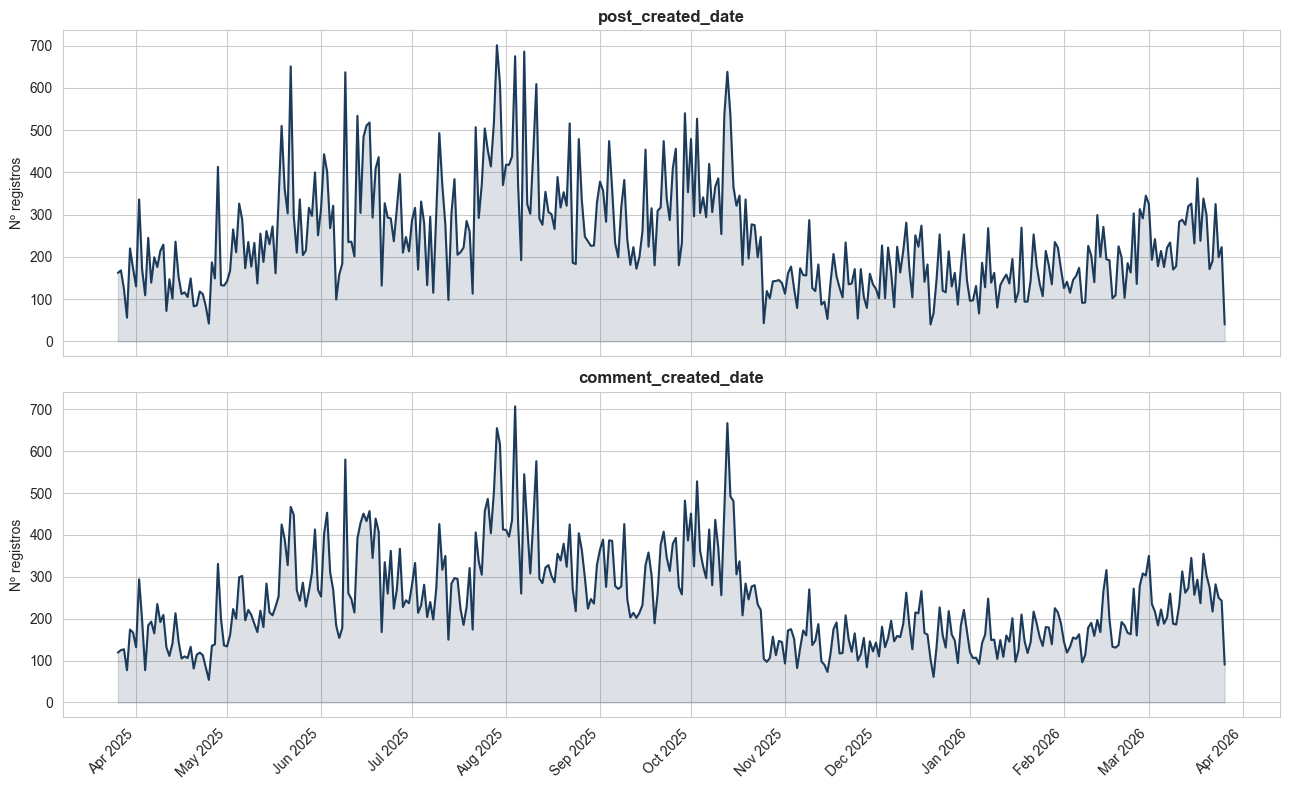

In [28]:
fig, axes = plt.subplots(len(date_cols), 1, figsize=(13, 4 * len(date_cols)), sharex=True)

for ax, col in zip(axes, date_cols):
    daily = (
        processed_data
        .with_columns(pl.col(col).dt.truncate("1d").alias("day"))
        .group_by("day")
        .agg(pl.len().alias("count"))
        .sort("day")
    )

    days   = daily["day"].to_list()
    counts = daily["count"].to_list()

    ax.plot(days, counts, color="#1C3B5A", linewidth=1.5)
    ax.fill_between(days, counts, alpha=0.15, color="#1C3B5A")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Nº registros")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [29]:
processed_data['extraction_time'].unique()

extraction_time
"datetime[μs, UTC]"
2026-03-26 10:09:05.123482 UTC


#### Query variables

In [30]:
query_cols = [
    'extraction_query',
    'post_subreddit'
]

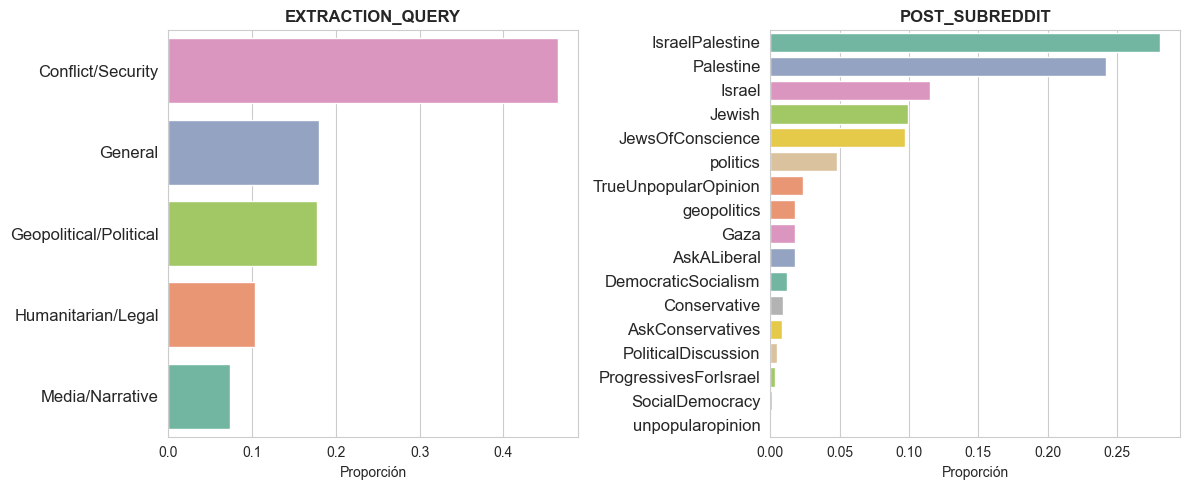

In [34]:
plot_cat_distribution(
    df = processed_data,
    cat_cols = query_cols,
    x_rotation = 90,
    order=True,
    orient="h", 
    max_cols=2
)

### Scores

In [33]:
plot_quant_distribution(
    df = processed_data,
    quant_cols = 
)

SyntaxError: expected argument value expression (1134620192.py, line 3)